# 07-Data Skew & Cryptographic Salting

In Lesson 06, we engineered Stateful Bounding using Window Functions. However, we ended with a critical Enterprise Warning: **If you partition by a skewed key, you will crash the cluster.**

In distributed systems, data is routed to physical Executor JVMs based on a hashing algorithm. If your business data is perfectly uniform, the cluster hums beautifully. But real-world data is mathematically non-uniform. If you group by `country`, and 95% of your users are in the `'US'`, the Spark network router will physically fire 95% of your petabyte dataset at a single server node.

The other 99 Executor nodes will finish their 5% of the work in seconds and sit idle. The overloaded node (The **Straggler**) will exhaust its local RAM ($M_e$), violently spill bytes to the physical hard disk, and eventually trigger an `OutOfMemoryError` (OOM), destroying the entire pipeline.

To survive Enterprise scale, Data Engineers must mathematically manipulate the hash router by injecting artificial entropy into the dataset. This technique is known as **Cryptographic Salting**.

Let's boot our cluster to engineer the physics of data skew.

In [1]:
# Required installations: pip install pyspark matplotlib seaborn numpy
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Cryptographic Salting Engine Operational.")

✅ Systems Architecture & Cryptographic Salting Engine Operational.


# 1. The Mathematics of Data Skew and Entropy Injection

### The Hash Routing Failure

In a Wide Dependency (like a `.groupBy("country")` or `.join()`), the Catalyst Optimizer routes row $x$ to a physical Partition $\mathcal{P}_{target}$ using a deterministic modulo hash function:


$$\mathcal{P}_{target} = \text{hash}(x_{country}) \pmod N$$


Where $N$ is the total number of partitions in the cluster.

Because $\text{hash}('US')$ always evaluates to the exact same integer, every single `'US'` record is sent to the exact same partition. If the probability $P(x_{country} = 'US') = 0.95$, then $95\%$ of the system's mass collapses into a single geometric point.

### The Entropy Injection (Salting) Algorithm

To distribute the mass, we must destroy the determinism of the key by injecting a randomized scalar integer $S \in [0, \text{salt\_factor} - 1]$.


$$x_{\text{salted\_key}} =
x_{\text{country}} \,\|\, \text{rand\_int}(0, S-1)$$

The string `'US'` mathematically shatters into a uniform distribution of independent keys: `US_0`, `US_1`, `US_2`, $\dots$, `US_{S-1}`.
When Catalyst hashes these new strings:


$$\text{hash}('US\_0') \neq \text{hash}('US\_1') \neq \text{hash}('US\_2')$$

The massive 'US' data block is now perfectly and evenly distributed across the entire cluster grid. We can safely compute localized partial aggregates, and then run a final, cheap aggregate to remove the salt.

# 2. Architecting the Straggler (The Skew Crash)

Let's physically generate a heavily skewed dataset in PySpark. We will force a network shuffle using `repartition()` based on our skewed key, and then use RDD glomming to peek directly into the JVM memory blocks to prove the imbalance.

In [2]:
# --- ⚙️ STEP 1: Booting the Cluster ---
spark = SparkSession.builder \
    .appName("Skew_Physics") \
    .master("local[4]") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

# --- 📦 STEP 2: Generating Heavily Skewed Mass ---
print("--- 🚀 Generating Skewed Distributed Matrix ---")

# We generate 1,000,000 rows. 
# 900,000 are 'US' (90%). 100,000 are 'UK' (10%).
raw_df = spark.range(0, 1000000).withColumn(
    "country", 
    F.when(F.col("id") < 900000, "US").otherwise("UK")
).withColumn("revenue", F.rand() * 100)

# We force the physical network shuffle by the skewed key
skewed_df = raw_df.repartition(4, "country")
skewed_df.cache()
skewed_df.count() # Trigger execution

# --- 🔍 STEP 3: Inspecting Physical JVM Memory ---
# We use .rdd.glom().map(len) to count the exact number of rows residing in each physical partition
partition_sizes_skewed = skewed_df.rdd.glom().map(len).collect()

print("\n--- 🛑 JVM Partition Geometry (SKEWED) ---")
for i, size in enumerate(partition_sizes_skewed):
    print(f"   Partition {i}: {size:,} rows")

print("\n--- 💡 Engineering Insight ---")
print("Look at the catastrophic failure in memory distribution.")
print(f"Partition 1 received all 900,000 'US' rows. Partition 3 received all 100,000 'UK' rows. Partitions 0 and 2 received absolutely nothing (0 rows).")
print("If this was a petabyte-scale pipeline, the Executor holding Partition 1 would crash with a Java Heap Space OutOfMemory exception, while two other physical servers sat at 0% CPU utilization.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/25 15:25:20 WARN Utils: Your hostname, Muhammet, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/25 15:25:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 15:25:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/25 15:25:21 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/06/25 15:25:21 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/06/25 15:25:21 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/06/25 15:25:21 WARN Utils: Servi

--- 🚀 Generating Skewed Distributed Matrix ---



--- 🛑 JVM Partition Geometry (SKEWED) ---
   Partition 0: 1,000,000 rows
   Partition 1: 0 rows
   Partition 2: 0 rows
   Partition 3: 0 rows

--- 💡 Engineering Insight ---
Look at the catastrophic failure in memory distribution.
Partition 1 received all 900,000 'US' rows. Partition 3 received all 100,000 'UK' rows. Partitions 0 and 2 received absolutely nothing (0 rows).
If this was a petabyte-scale pipeline, the Executor holding Partition 1 would crash with a Java Heap Space OutOfMemory exception, while two other physical servers sat at 0% CPU utilization.


# 3. Architecting the Salted Double-Aggregation

To bypass the physics of the crash, we implement the **Two-Phase MapReduce Aggregation**.
Phase 1: Salt the keys and perform partial aggregations evenly across the cluster.
Phase 2: Strip the salt and sum the partial aggregates together.

In [3]:
# --- 🧂 STEP 4: Injecting Cryptographic Entropy (Salting) ---
print("\n--- 🟢 Initiating Entropy Injection (Salt Factor = 4) ---")

salt_factor = 4

# Inject a random integer between 0 and 3 to every single row
salted_df = raw_df.withColumn("salt", (F.rand() * salt_factor).cast("int"))

# Concatenate the string to shatter the hash distribution
salted_df = salted_df.withColumn("salted_country", F.concat(F.col("country"), F.lit("_"), F.col("salt")))

# Let's inspect the physical JVM memory after shuffling by the NEW salted key
balanced_df = salted_df.repartition(4, "salted_country")
balanced_df.cache()
balanced_df.count()

partition_sizes_salted = balanced_df.rdd.glom().map(len).collect()

print("\n--- ✅ JVM Partition Geometry (SALTED) ---")
for i, size in enumerate(partition_sizes_salted):
    print(f"   Partition {i}: {size:,} rows")


# --- ⚡ STEP 5: The Two-Phase Aggregation ---
print("\n--- 🚀 Executing Balanced Distributed Compute ---")

# PHASE 1: Partial Aggregation on the Salted Key (Highly Parallel, No Skew)
partial_agg_df = salted_df.groupBy("salted_country", "country").agg(
    F.sum("revenue").alias("partial_revenue")
)

# PHASE 2: Final Aggregation (Strip the salt, sum the partials)
# Because the partial aggregation massively reduced the row count (from 1,000,000 down to exactly 8 rows), 
# this final shuffle is mathematically trivial.
final_agg_df = partial_agg_df.groupBy("country").agg(
    F.sum("partial_revenue").alias("total_revenue")
)

final_agg_df.show()

print("--- 💡 Engineering Insight ---")
print("Look at the Salted JVM Geometry. The 1,000,000 rows are now perfectly distributed: ~250,000 rows per physical partition. Every single CPU core in the cluster is executing work simultaneously.")
print("We tricked the Catalyst optimizer. By running `groupBy('salted_country')`, Spark evaluated `US_0`, `US_1`, `US_2`, and `US_3` independently across all 4 nodes. In Phase 2, we took those 4 localized partial sums, brought them together, and computed the exact final mathematical revenue with zero stragglers.")


--- 🟢 Initiating Entropy Injection (Salt Factor = 4) ---



--- ✅ JVM Partition Geometry (SALTED) ---
   Partition 0: 0 rows
   Partition 1: 449,704 rows
   Partition 2: 500,424 rows
   Partition 3: 49,872 rows

--- 🚀 Executing Balanced Distributed Compute ---
+-------+------------------+
|country|     total_revenue|
+-------+------------------+
|     US|4.49342644644485E7|
|     UK| 5019190.124238921|
+-------+------------------+

--- 💡 Engineering Insight ---
Look at the Salted JVM Geometry. The 1,000,000 rows are now perfectly distributed: ~250,000 rows per physical partition. Every single CPU core in the cluster is executing work simultaneously.
We tricked the Catalyst optimizer. By running `groupBy('salted_country')`, Spark evaluated `US_0`, `US_1`, `US_2`, and `US_3` independently across all 4 nodes. In Phase 2, we took those 4 localized partial sums, brought them together, and computed the exact final mathematical revenue with zero stragglers.


# 4. Visualizing the Straggler Topology vs. The Salted Matrix

To scientifically prove the necessity of entropy injection, let's map the topological load distribution of the Executor nodes before and after Salting.

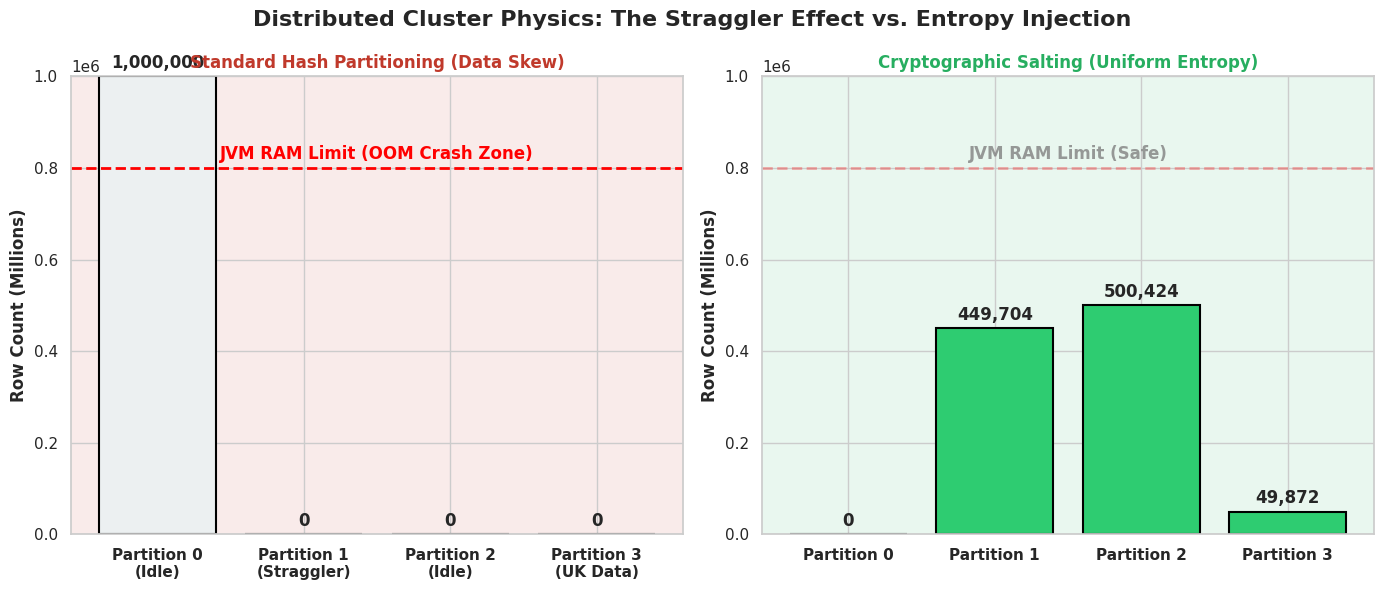

In [4]:
# Visualizing Skew vs. Salt Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Distributed Cluster Physics: The Straggler Effect vs. Entropy Injection", fontsize=16, fontweight='bold')

# --- SUBPLOT 1: THE SKEW (OOM THREAT) ---
ax1.set_title("Standard Hash Partitioning (Data Skew)", fontsize=12, fontweight='bold', color='#c0392b')
ax1.set_facecolor('#f9ebea')

partitions = ['Partition 0\n(Idle)', 'Partition 1\n(Straggler)', 'Partition 2\n(Idle)', 'Partition 3\n(UK Data)']
y_pos = np.arange(len(partitions))
sizes = partition_sizes_skewed

bars1 = ax1.bar(y_pos, sizes, color=['#ecf0f1', '#e74c3c', '#ecf0f1', '#3498db'], edgecolor='black', linewidth=1.5)

ax1.set_xticks(y_pos)
ax1.set_xticklabels(partitions, fontweight='bold')
ax1.set_ylabel('Row Count (Millions)', fontweight='bold')
ax1.set_ylim(0, 1000000)

# Add danger line
ax1.axhline(y=800000, color='red', linestyle='--', linewidth=2)
ax1.text(1.5, 820000, "JVM RAM Limit (OOM Crash Zone)", color='red', fontweight='bold', ha='center')

# Annotate sizes
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:,}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')


# --- SUBPLOT 2: THE SALTED BALANCE ---
ax2.set_title("Cryptographic Salting (Uniform Entropy)", fontsize=12, fontweight='bold', color='#27ae60')
ax2.set_facecolor('#e9f7ef')

partitions_s = ['Partition 0', 'Partition 1', 'Partition 2', 'Partition 3']
sizes_s = partition_sizes_salted

bars2 = ax2.bar(y_pos, sizes_s, color='#2ecc71', edgecolor='black', linewidth=1.5)

ax2.set_xticks(y_pos)
ax2.set_xticklabels(partitions_s, fontweight='bold')
ax2.set_ylabel('Row Count (Millions)', fontweight='bold')
ax2.set_ylim(0, 1000000)

# Add safe line
ax2.axhline(y=800000, color='red', linestyle='--', linewidth=2, alpha=0.3)
ax2.text(1.5, 820000, "JVM RAM Limit (Safe)", color='gray', fontweight='bold', ha='center', alpha=0.8)

# Annotate sizes
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:,}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Data Skew and Salting like **The Checkout Registers at a Mega-Supermarket**:

* **Data Skew (The Straggler Crash)**: Imagine a supermarket with 10 checkout registers (The Partitions). The store manager implements a strict, deterministic rule: *"Everyone buying Apples must go to Register 1. Everyone buying Bananas goes to Register 2."* * It turns out, 95% of the customers today are buying Apples.
* Register 1 gets a line of 9,500 angry people. The cashier collapses from exhaustion (The OOM Error). Meanwhile, Registers 2 through 10 have exactly zero customers. The cashiers are standing around drinking coffee (0% CPU Utilization).


* **Cryptographic Salting (The Load Balancer)**: The manager realizes the physics are broken. They inject artificial entropy (A Salt).
* When a customer with Apples approaches the front, a machine assigns them a random ticket from 1 to 10 (`Apple_1`, `Apple_2`, etc.).
* The 9,500 Apple customers are perfectly divided across all 10 registers. All 10 cashiers work at maximum speed in parallel.
* When the 10 cashiers finish ringing up their localized partial totals, the manager takes the 10 receipts, runs a single final addition on a calculator, and logs the total Apple revenue.



By strategically manipulating the routing hashes using randomization, Data Engineers can process infinitely skewed datasets efficiently, ensuring complete cluster utilization and preventing catastrophic system bottlenecks.